Нейронные сети \
  Свёрточные (конволюционные нейронные сети) [CNN] \
      Используются в основном в задачах компьютерного зрения \
  Рекурентные нейросети [RNN] \
      Распознавание рукописного текста (эммедингии текстов) \
  Генеративные созтязательные сети [GAN] \
      Создание художественных и музыкальных произведений \
  Базовый Многослойный перцептон \

In [1]:
!pip install tensorflow


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Классификация
1. Загрузка изображения
2. Масштабирование
3. Нормализация
4. Выбор модели
5. Загрузка изображения в модель и получение предсказания

In [3]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

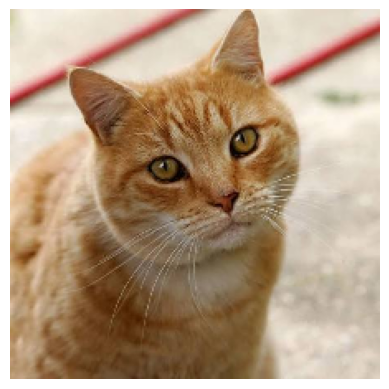

In [31]:
img_path = 'assets/cat.png'
img = image.load_img(img_path, target_size=(224, 224))
plt.imshow(img)
plt.axis('off')

In [32]:
img_array = image.img_to_array(img)
print(img_array.shape, img_array[100, 100])
print(np.min(img_array), np.max(img_array))

(224, 224, 3) [28. 11.  1.]
0.0 255.0


In [33]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.resnet50 import decode_predictions

In [34]:
img_batch = np.expand_dims(img_array, axis=0)
img_preprocessed = preprocess_input(img_batch)
img_preprocessed.shape

(1, 224, 224, 3)

In [35]:
print(img_preprocessed.shape, img_preprocessed[0, 100, 100])
print(np.min(img_preprocessed), np.max(img_preprocessed))

(1, 224, 224, 3) [-102.939 -105.779  -95.68 ]
-121.68 133.061


In [36]:
model = ResNet50()

In [37]:
prediction = model.predict(img_preprocessed)
decode_predictions(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


[[('n02123159', 'tiger_cat', np.float32(0.51637113)),
  ('n02124075', 'Egyptian_cat', np.float32(0.23910813)),
  ('n02123045', 'tabby', np.float32(0.22294343)),
  ('n04589890', 'window_screen', np.float32(0.004804046)),
  ('n02127052', 'lynx', np.float32(0.002768547))]]

In [58]:
TRAIN_DATA_DIR = 'assets/fine_tune/train'
VALIDATION_DATA_DIR = 'assets/fine_tune/test'
TRAIN_SAMPLES = 6026
VALIDATION_SAMPLES = 2944
IMG_WIDTH = 224
IMG_HEIGHT = 224
BATCH_SIZE = 256
NUM_ClASSES = 2

In [59]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Flatten,
    Dense,
    Dropout,
    GlobalAveragePooling2D,
)
from tensorflow.keras.applications.mobilenet import MobileNet, preprocess_input
from tensorflow.keras.optimizers import Adam
import math

In [60]:
train_datagen = image.ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
)

In [61]:
train_gen = train_datagen.flow_from_directory(
    TRAIN_DATA_DIR,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=1,
    class_mode='categorical'
)

val_gen = train_datagen.flow_from_directory(
    VALIDATION_DATA_DIR,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    shuffle=False,
    class_mode='categorical'
)

Found 6026 images belonging to 2 classes.
Found 2944 images belonging to 2 classes.


In [62]:
model = MobileNet(weights='imagenet', include_top=False, input_shape=(IMG_WIDTH, IMG_HEIGHT, 3))

In [63]:
for layer in model.layers[:]:
    layer.trainable = False

inp = Input(shape=(IMG_WIDTH, IMG_HEIGHT, 3))

custom_model = model(inp)
custom_model = GlobalAveragePooling2D()(custom_model)
custom_model = Dense(64, activation='relu')(custom_model)
custom_model = Dropout(0.5)(custom_model)
prediction = Dense(NUM_ClASSES, activation='softmax')(custom_model)

target_model = Model(inputs=inp, outputs=prediction)

In [64]:
target_model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(),
    metrics=['acc']
)

In [67]:
num_steps_train = math.ceil(float(TRAIN_SAMPLES / BATCH_SIZE))
num_steps_val = math.ceil(float(VALIDATION_SAMPLES / BATCH_SIZE))

target_model.fit(
    train_gen,
    steps_per_epoch = num_steps_train,
    epochs = 2,
    validation_data=val_gen,
    validation_steps=num_steps_val,
)

print(val_gen.class_indices)
target_model.save('assets/fine_tune/model.pth')

Epoch 1/2
 3/24 ━━━━━━━━━━━━━━━━━━━━ 1:16 4s/step - acc: 0.9655 - loss: 0.0868

KeyboardInterrupt: 